In [4]:
import pandas as pd
#grid_df is the human mobility dataset; traj_df is the Massive step check-ins
grid_df = pd.read_csv("~/Downloads/humob_datasets/10836269/cell_POIcat.csv.gz")
poi_map = pd.read_csv("~/Downloads/humob_datasets/10836269/POI_datacategories.csv", header=None)
traj_df = pd.read_csv("~/Downloads/japan_checkins.csv")
poi_cat = pd.read_csv("~/Downloads/Foursquare_mapping.csv")

In [5]:
# Massive-STEP dataset - add zone
mapping = poi_cat.set_index("Category ID")["Category Label Level 1"]
traj_df['zone'] = traj_df["venue_category_id"].map(mapping)

In [10]:
# Human Mob 2023 - add category mapping
grid_df['POI_name'] = (grid_df['POIcategory'] - 1).map(poi_map.iloc[:,0])
# check mapping is correct
# grid_df[grid_df["POIcategory"] == 85]
# Apply the same zone for Human Mob 2023
zone_mapping = {
    "Food": "Dining and Drinking",
    "Shopping": "Retail",
    "Entertainment": "Arts and Entertainment",
    "Japanese restaurant": "Dining and Drinking",
    "Western restaurant": "Dining and Drinking",
    "Eat all you can restaurant": "Dining and Drinking",
    "Chinese restaurant": "Dining and Drinking",
    "Indian restaurant": "Dining and Drinking",
    "Ramen restaurant": "Dining and Drinking",
    "Curry restaurant": "Dining and Drinking",
    "BBQ restaurant": "Dining and Drinking",
    "Hot pot restaurant": "Dining and Drinking",
    "Bar": "Dining and Drinking", ##"Nightlife Spot"
    "Diner": "Dining and Drinking",
    "Creative cuisine": "Dining and Drinking",
    "Organic cuisine": "Dining and Drinking",
    "Pizza": "Dining and Drinking",
    "Café": "Dining and Drinking",
    "Tea Salon": "Dining and Drinking",
    "Bakery": "Dining and Drinking",
    "Sweets ": "Dining and Drinking",
    "Wine Bar": "Dining and Drinking", ##"Nightlife Spot",
    "Pub": "Dining and Drinking", ##"Nightlife Spot",
    "Disco": "Nightlife Spot",
    "Beer Garden": "Dining and Drinking", ##"Nightlife Spot",
    "Fast Food": "Dining and Drinking",
    "Karaoke": "Arts and Entertainment", 
    "Cruising": "Travel and Transportation", 
    "Theme Park Restaurant": "Dining and Drinking",
    "Amusement Restaurant": "Dining and Drinking",
    "Other Restaurants": "Dining and Drinking",
    "Glasses": "Retail",
    "Drug Store": "Retail",
    "Electronics Store": "Retail",
    "DIY Store": "Retail",
    "Convenience Store": "Retail",
    "Recycle Shop": "Retail",
    "Interior Shop": "Retail",
    "Sports Store": "Retail",
    "Clothes Store": "Retail",
    "Grocery Store": "Retail",
    "Online Grocery Store": "Retail",
    "Sports Recreation": "Sports and Recreation",
    "Game Arcade": "Arts and Entertainment",
    "Swimming Pool": "Sports and Recreation",
    "Hotel": "Travel and Transportation",
    "Park": "Landmarks and Outdoors",
    "Transit Station": "Travel and Transportation",
    "Parking Area": "Travel and Transportation",
    "Casino": "Arts and Entertainment",
    "Hospital": "Health and Medicine",
    "Pharmacy": "Retail", ##"Health and Medicine", 
    "Chiropractic": "Health and Medicine",
    "Elderly Care Home": "Health and Medicine", #Check
    "Fishing": "Sports and Recreation",
    "School": "Community and Government",
    "Cram School": "Community and Government",
    "Kindergarten": "Community and Government",
    "Real Estate": "Business and Professional Services",
    "Home Appliances": "Retail",
    "Post Office": "Community and Government",
    "Laundry ": "Business and Professional Services",
    "Driving School": "Community and Government",
    "Wedding Ceremony": "Business and Professional Services", ##"Event",
    "Cemetary": "Community and Government",
    "Bank": "Business and Professional Services",
    "Vet": "Health and Medicine",
    "Hot Spring": "Landmarks and Outdoors",
    "Hair Salon": "Business and Professional Services", #Okay
    "Lawyer Office": "Business and Professional Services",
    "Recruitment Office": "Business and Professional Services",
    "City Hall": "Community and Government",
    "Community Center": "Community and Government",
    "Church": "Community and Government",
    "Retail Store": "Retail",
    "Accountant Office": "Business and Professional Services",
    "IT Office": "Business and Professional Services",
    "Publisher Office": "Business and Professional Services",
    "Building Material": "Retail",
    "Gardening": "Business and Professional Services",
    "Heavy Industry": "Business and Professional Services",
    "NPO": "Community and Government",
    "Utility Copany": "Community and Government",
    "Port": "Travel and Transportation",
    "Research Facility": "Business and Professional Services",
}

grid_df["zone"] = grid_df["POI_name"].map(zone_mapping)

print("Unmapped categories:")
print(grid_df[grid_df["zone"].isna()])

Unmapped categories:
Empty DataFrame
Columns: [x, y, POIcategory, POI_count, POI_name, zone]
Index: []


In [49]:
# Method 1: 11 features with norlimalised proportion by counts

pivot = grid_df.pivot_table(
    index=["x","y"],
    columns="zone",
    values="POI_count",
    aggfunc="sum",
    fill_value=0
)
# ensure all categories exist
categories = [
    "Arts and Entertainment",
    "Business and Professional Services",
    "Community and Government",
    "Dining and Drinking",
    "Event",
    "Health and Medicine",
    "Landmarks and Outdoors",
    "Nightlife Spot",
    "Retail",
    "Sports and Recreation",
    "Travel and Transportation"
]

pivot = pivot.reindex(columns=categories, fill_value=0)

# compute total count
pivot["total_count"] = pivot.sum(axis=1)

# compute normalised proportions
proportions = pivot[categories].div(pivot["total_count"], axis=0)
proportions = proportions.fillna(0)

# compute entropy

import numpy as np

epsilon = 1e-12

entropy = -np.sum(
    proportions * np.log(proportions + epsilon),
    axis=1
)

pivot["entropy"] = entropy


# feature
final_features = pd.concat(
    [proportions, pivot[["total_count", "entropy"]]],
    axis=1
).reset_index()

print(final_features)

zone     x    y  Arts and Entertainment  Business and Professional Services  \
0        1    1                     0.0                            0.200000   
1        1    2                     0.0                            0.333333   
2        1    3                     0.0                            0.125000   
3        1    4                     0.0                            0.300000   
4        1    5                     0.0                            0.375000   
...    ...  ...                     ...                                 ...   
20141  200  196                     0.0                            0.333333   
20142  200  197                     0.0                            0.400000   
20143  200  198                     0.0                            0.200000   
20144  200  199                     0.0                            0.315789   
20145  200  200                     0.0                            0.281250   

zone   Community and Government  Dining and Drinkin

In [50]:
# Method 2: Word2Vec
from gensim.models import Word2Vec

# Prepare “sentences” for Word2Vec: each cell = repeated zones by POI_count
cells = []
cell_keys = []  # keep track of (x,y) for merging later
for (x, y), group in grid_df.groupby(["x","y"]):
    cell_categories = []
    for _, row in group.iterrows():
        cell_categories += [row['zone']] * int(row['POI_count'])
    cells.append(cell_categories)
    cell_keys.append((x,y))

# Train Word2Vec on cells
embedding_size = 16  # choose as needed
model = Word2Vec(
    sentences=cells,
    vector_size=embedding_size,
    window=3,
    min_count=1,
    workers=4,
    sg=1
)

# Compute weighted embedding per cell
embeddings_list = []

for (x, y), group in grid_df.groupby(["x","y"]):
    total_count = group['POI_count'].sum()
    emb = np.zeros(embedding_size)
    for _, row in group.iterrows():
        weight = row['POI_count'] / total_count
        emb += weight * model.wv[row['zone']]
    embeddings_list.append([x, y] + emb.tolist())

# Convert embeddings to DataFrame
emb_cols = [f'emb_{i}' for i in range(embedding_size)]
emb_df = pd.DataFrame(embeddings_list, columns=['x','y'] + emb_cols)

# Merge embeddings with your existing features
final_features_with_emb = final_features.merge(emb_df, on=['x','y'])

print(final_features_with_emb.head())
print(final_features_with_emb.shape)

   x  y  Arts and Entertainment  Business and Professional Services  \
0  1  1                     0.0                            0.200000   
1  1  2                     0.0                            0.333333   
2  1  3                     0.0                            0.125000   
3  1  4                     0.0                            0.300000   
4  1  5                     0.0                            0.375000   

   Community and Government  Dining and Drinking  Event  Health and Medicine  \
0                  0.400000                  0.0    0.0               0.0000   
1                  0.333333                  0.0    0.0               0.0000   
2                  0.562500                  0.0    0.0               0.0625   
3                  0.500000                  0.0    0.0               0.0000   
4                  0.250000                  0.0    0.0               0.0000   

   Landmarks and Outdoors  Nightlife Spot  ...     emb_6     emb_7     emb_8  \
0           

In [ ]:
# Method 3: LDA

# covert grid cells into LDA
grid_docs = []

for (x,y), g in grid_df.groupby(['x','y']):
    
    tokens = []
    
    for _, row in g.iterrows():
        tokens += [row['zone']] * int(row['POI_count'])
    
    grid_docs.append(tokens)
# chek output
# grid_docs[0]

from gensim import corpora

dictionary = corpora.Dictionary(grid_docs)

corpus = [dictionary.doc2bow(doc) for doc in grid_docs]

# Train LDA functional zone model
import gensim

lda = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,   # 10 target zones
    passes=20,
    random_state=42
)

for i in range(5):
    print(lda.print_topic(i))
    
grid_topics = []

for doc in corpus:
    grid_topics.append(lda.get_document_topics(doc))

import numpy as np

num_topics = lda.num_topics

grid_vectors = []

for doc in corpus:
    
    vec = np.zeros(num_topics)
    
    for topic, prob in lda.get_document_topics(doc):
        vec[topic] = prob
    
    grid_vectors.append(vec)


# Make DataFrame from grid_vectors
lda_df = pd.DataFrame(grid_vectors, columns=[f'lda_topic_{i}' for i in range(num_topics)])

# Add x, y coordinates
cell_keys = [ (x, y) for (x, y), _ in grid_df.groupby(['x','y']) ]
lda_df['x'] = [key[0] for key in cell_keys]
lda_df['y'] = [key[1] for key in cell_keys]

lda_df = lda_df[['x','y'] + [f'lda_topic_{i}' for i in range(num_topics)]]

print(lda_df.head())    

In [17]:
bow = dictionary.doc2bow(['Dining and Drinking'])

lda.get_document_topics(bow)

[(0, 0.050000027),
 (1, 0.050000012),
 (2, 0.05000001),
 (3, 0.05000952),
 (4, 0.050002623),
 (5, 0.5499878),
 (6, 0.05000001),
 (7, 0.05000002),
 (8, 0.05000001),
 (9, 0.05000001)]

In [ ]:
## Visulisation

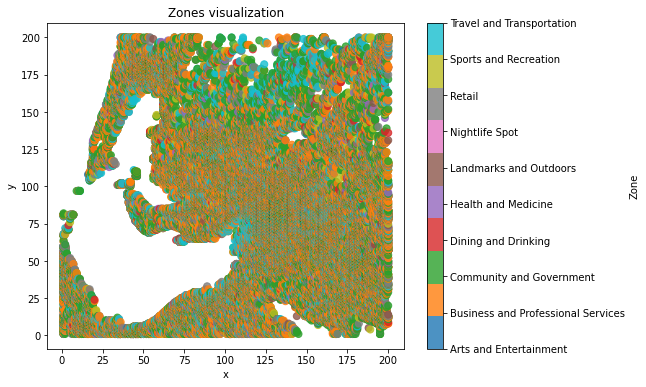

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

categories = grid_df['zone'].astype('category').cat.categories
codes = grid_df['zone'].astype('category').cat.codes
zone_mapping = dict(enumerate(categories)) 

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    grid_df['x'], grid_df['y'],
    c=codes,
    cmap='tab10',  # 10 discrete colors
    s=50, alpha=0.8
)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Zones visualization')

# Colorbar with category names
cbar = plt.colorbar(scatter, ticks=range(len(categories)))
cbar.ax.set_yticklabels([zone_mapping[i] for i in range(len(categories))])
cbar.set_label('Zone')
plt.show()

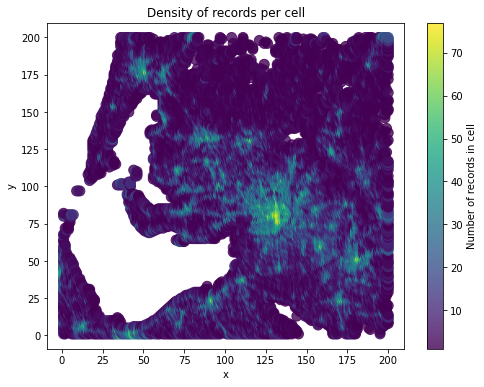

In [42]:
cell_counts = grid_df.groupby(['x','y']).size().reset_index(name='count')

plt.figure(figsize=(8,6))
plt.scatter(
    cell_counts['x'], cell_counts['y'],
    c=cell_counts['count'],
    cmap='viridis',
    s=100,
    alpha=0.8
)
plt.colorbar(label='Number of records in cell')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Density of records per cell')
plt.show()

In [33]:
grid_df.groupby('zone')['POI_count'].sum().sort_values(ascending=False)

zone
Business and Professional Services    166745
Retail                                 97669
Community and Government               69726
Dining and Drinking                    64483
Travel and Transportation              36658
Health and Medicine                    32684
Sports and Recreation                  14007
Landmarks and Outdoors                 11692
Arts and Entertainment                  1505
Nightlife Spot                             2
Name: POI_count, dtype: int64

In [32]:
traj_df.groupby('zone').size().sort_values(ascending=False)

zone
Travel and Transportation             837751
Dining and Drinking                   441853
Retail                                370310
Arts and Entertainment                177996
Landmarks and Outdoors                173340
Community and Government               88438
Business and Professional Services     54933
Sports and Recreation                  17201
Health and Medicine                     8299
Event                                   2640
Nightlife Spot                          2146
dtype: int64